In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
path = "/content/gdrive/MyDrive/NurulFikri/ML/Pertemuan07"

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt



df=pd.read_csv(path + '/data/dataset_satelit.csv')


In [ ]:
print("=== Informasi Dataset ===")
print(df.info())
print("\n=== Lima Baris Pertama ===")
print(df.head())


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   No         594 non-null    int64  
 1   Longitude  594 non-null    float64
 2   Lattitude  594 non-null    float64
 3   N          594 non-null    float64
 4   P          594 non-null    float64
 5   K          593 non-null    float64
 6   Ca         594 non-null    float64
 7   Mg         594 non-null    object 
 8   Fe         594 non-null    float64
 9   Mn         594 non-null    float64
 10  Cu         594 non-null    float64
 11  Zn         594 non-null    float64
 12  B          594 non-null    float64
 13  b12        594 non-null    float64
 14  b11        594 non-null    float64
 15  b9         594 non-null    float64
 16  b8a        594 non-null    float64
 17  b8         594 non-null    float64
 18  b7         594 non-null    float64
 19  b6         594 non-null 

In [ ]:
print(df.columns)

Index(['No', 'Longitude', 'Lattitude', 'N', 'P', 'K', 'Ca', 'Mg', 'Fe', 'Mn',
       'Cu', 'Zn', 'B', 'b12', 'b11', 'b9', 'b8a', 'b8', 'b7', 'b6', 'b5',
       'b4', 'b3', 'b2', 'b1', 'Sigma_VV', 'Sigma_VH', 'plia', 'lia', 'iafe',
       'gamma0_vv', 'gamma0_vh', 'beta0_vv', 'beta0_vh'],
      dtype='object')


In [ ]:
fitur = ['P', 'K', 'Ca', 'Mg', 'Fe', 'Mn', 'Cu', 'Zn', 'B']
target = 'N'

X = df[fitur]
y = df[target]

In [ ]:
print("\nJumlah Missing Value:")
print(df[fitur + [target]].isnull().sum())


Jumlah Missing Value:
P     0
K     1
Ca    0
Mg    0
Fe    0
Mn    0
Cu    0
Zn    0
B     0
N     0
dtype: int64


In [ ]:
# Replace ')' in the 'Mg' column with NaN
df['Mg'] = df['Mg'].replace(')', np.nan)

# Convert the 'Mg' column to numeric, coercing errors
df['Mg'] = pd.to_numeric(df['Mg'], errors='coerce')

# Update X with the cleaned 'Mg' column
X = df[fitur]

# Fill missing values in X with the median of each column
X = X.fillna(X.median())

# Fill missing values in y with the mode (most frequent value)
y = y.fillna(y.mode()[0])

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (475, 9)
Shape of X_test: (119, 9)
Shape of y_train: (475,)
Shape of y_test: (119,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

models = {
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "SVM Regressor": SVR(kernel='rbf'),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"\n=== {name} ===")
    print("Mean Absolute Error:", round(mean_absolute_error(y_test, y_pred), 4))
    print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 4))
    print("R-squared:", round(r2_score(y_test, y_pred), 4))


=== Random Forest Regressor ===
Mean Absolute Error: 0.1716
Mean Squared Error: 0.0494
R-squared: 0.6741

=== SVM Regressor ===
Mean Absolute Error: 0.1985
Mean Squared Error: 0.067
R-squared: 0.5576

=== KNN Regressor ===
Mean Absolute Error: 0.2157
Mean Squared Error: 0.08
R-squared: 0.472


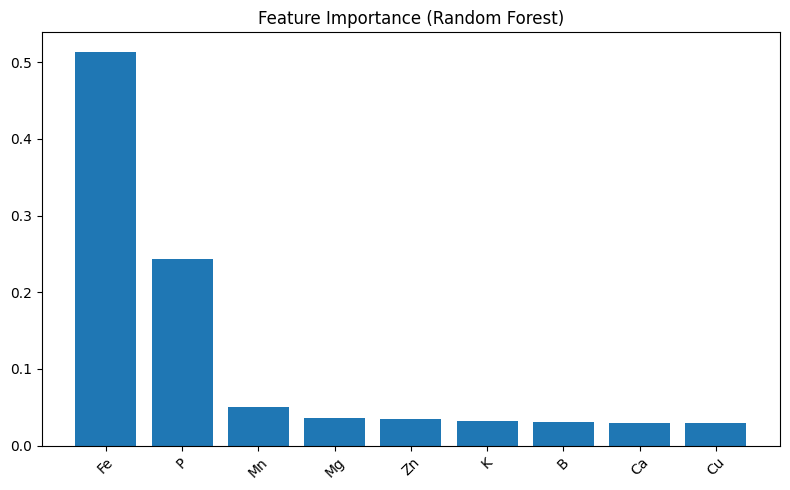

In [ ]:
rf_model = models["Random Forest Regressor"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [fitur[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()